**Imports**

In [1]:
!pip install -q tensorflow-io
!apt-get install -y -qq python3-opencv git

import os, random, itertools, math, cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import (Input, Reshape, LayerNormalization, MultiHeadAttention,
                                     Dense, GlobalAveragePooling1D, Dropout, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
SEED = 7
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

Selecting previously unselected package python3-numpy.
(Reading database ... 128663 files and directories currently installed.)
Preparing to unpack .../python3-numpy_1%3a1.21.5-1ubuntu22.04.1_amd64.deb ...
Unpacking python3-numpy (1:1.21.5-1ubuntu22.04.1) ...
Selecting previously unselected package python3-opencv:amd64.
Preparing to unpack .../python3-opencv_4.5.4+dfsg-9ubuntu4+jammy1_amd64.deb ...
Unpacking python3-opencv:amd64 (4.5.4+dfsg-9ubuntu4+jammy1) ...
Setting up python3-numpy (1:1.21.5-1ubuntu22.04.1) ...
Setting up python3-opencv:amd64 (4.5.4+dfsg-9ubuntu4+jammy1) ...


2025-09-17 08:44:20.151044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758098660.341598      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758098660.396150      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.0


**Setting up Directories**

In [20]:
CANDIDATE_BASES = [
    "/kaggle/input/plantvillage/PlantVillage"
]

IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5
EPOCHS_STAGE3 = 5

def find_split_root():
    for base in CANDIDATE_BASES:
        if not os.path.isdir(base): 
            continue
        train_dir = os.path.join(base, "train")
        val_dir   = os.path.join(base, "val")
        valid_dir = os.path.join(base, "valid")

        if os.path.isdir(train_dir) and (os.path.isdir(val_dir) or os.path.isdir(valid_dir)):
            return train_dir, (val_dir if os.path.isdir(val_dir) else valid_dir)

TRAIN_DIR, VAL_DIR = find_split_root()
print("  TRAIN_DIR:", TRAIN_DIR)
print("  VAL_DIR  :", VAL_DIR)


  TRAIN_DIR: /kaggle/input/plantvillage/PlantVillage/train
  VAL_DIR  : /kaggle/input/plantvillage/PlantVillage/val


**Train Test Split**

In [4]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator()  

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


**Class Weights**

In [5]:
idx_to_class = {v:k for k,v in train_generator.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
num_classes = len(class_names)
print(f"Classes ({num_classes}):", class_names[:10], "..." if num_classes>10 else "")

# %% [Class Weights]
y_indices = train_generator.classes
class_weights_array = compute_class_weight(class_weight='balanced',
                                           classes=np.unique(y_indices),
                                           y=y_indices)
class_weight = {i: w for i, w in enumerate(class_weights_array)}
print("Computed class weights.")

Classes (38): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight'] ...
Computed class weights.


**Model Architecture**

In [6]:
def transformer_encoder(inputs, num_heads=4, ff_dim=256, name=None):
    x = LayerNormalization(epsilon=1e-6, name=None if not name else f"{name}_ln1")(inputs)
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim,
                              name=None if not name else f"{name}_mha")(x, x)
    x   = Add(name=None if not name else f"{name}_res1")([attn, inputs])

    x2  = LayerNormalization(epsilon=1e-6, name=None if not name else f"{name}_ln2")(x)
    ff1 = Dense(ff_dim, activation='relu', name=None if not name else f"{name}_ff1")(x2)
    ff2 = Dense(inputs.shape[-1], name=None if not name else f"{name}_ff2")(ff1)
    out = Add(name=None if not name else f"{name}_res2")([ff2, x])
    return out

def create_cnn_transformer_hybrid(input_shape=(299,299,3), num_classes=38,
                                  num_heads=4, ff_dim=256, dropout=0.3):
    cnn = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    for l in cnn.layers:
        l.trainable = False

    inp  = Input(shape=input_shape, name="input")
    feat = cnn(inp)                                         
    seq  = Reshape((feat.shape[1]*feat.shape[2], feat.shape[-1]))(feat) 

    x = transformer_encoder(seq, num_heads=num_heads, ff_dim=ff_dim, name="tx1")
    x = transformer_encoder(x,   num_heads=num_heads, ff_dim=ff_dim, name="tx2")

    x = GlobalAveragePooling1D(name="gap1d")(x)
    x = Dropout(dropout, name="head_do")(x)
    out = Dense(num_classes, activation='softmax', name="pred")(x)
    return Model(inp, out, name="CNN_Transformer_Hybrid")

model = create_cnn_transformer_hybrid(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                                      num_classes=num_classes)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1758098843.192986      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CNN_Transformer_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 299, 299,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 8, 8,      │ 21,802,784 │ input[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 2048)  │          0 │ inception_v3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ln1             │ (None, 64, 2048)  │      4,096 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_mha             │ (None, 64, 2048)  │  8,393,728 │ tx1_ln1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ tx1_ln1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_res1 (Add)      │ (None, 64, 2048)  │          0 │ tx1_mha[0][0],    │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ln2             │ (None, 64, 2048)  │      4,096 │ tx1_res1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ff1 (Dense)     │ (None, 64, 256)   │    524,544 │ tx1_ln2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_ff2 (Dense)     │ (None, 64, 2048)  │    526,336 │ tx1_ff1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx1_res2 (Add)      │ (None, 64, 2048)  │          0 │ tx1_ff2[0][0],    │
│                     │                   │            │ tx1_res1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ln1             │ (None, 64, 2048)  │      4,096 │ tx1_res2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_mha             │ (None, 64, 2048)  │  8,393,728 │ tx2_ln1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ tx2_ln1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_res1 (Add)      │ (None, 64, 2048)  │          0 │ tx2_mha[0][0],    │
│                     │                   │            │ tx1_res2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ln2             │ (None, 64, 2048)  │      4,096 │ tx2_res1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ff1 (Dense)     │ (None, 64, 256)   │    524,544 │ tx2_ln2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_ff2 (Dense)     │ (None, 64, 2048)  │    526,336 │ tx2_ff1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tx2_res2 (Add)      │ (None, 64, 2048)  │          0 │ tx2_ff2[0][0],    │
│                     │                   │            │ tx2_res1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap1d               │ (None, 2048)      │          0 │ tx2_res2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 40,786,246 (155.59 MB)

 Trainable params: 18,983,462 (72.42 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [6]:
ckpt1 = keras.callbacks.ModelCheckpoint("best_stage1.keras",
                                        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
ckpt2 = keras.callbacks.ModelCheckpoint("best_stage2.keras",
                                        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
ckpt3 = keras.callbacks.ModelCheckpoint("best_stage3.keras",
                                        monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)

reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                              patience=5, min_lr=1e-6, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15,
                                           restore_best_weights=True, verbose=1)


**Stage 1**

In [7]:
# [Stage 1 — cnn frozen]
for l in model.layers:
    l.trainable = False
# train some chunk(transformer blocks +head)
for l in model.layers[-20:]:
    l.trainable = True

history_s1 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE1,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[ckpt1, reduce_lr, early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1758061553.042180     131 service.cc:148] XLA service 0x7dcad0003820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758061553.042901     131 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1758061559.085938     131 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758061597.032162     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8019 - loss: 0.7422
Epoch 1: val_accuracy improved from -inf to 0.95958, saving model to best_stage1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1331s 904ms/step - accuracy: 0.8019 - loss: 0.7420 - val_accuracy: 0.9596 - val_loss: 0.1386 - learning_rate: 1.0000e-04
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9469 - loss: 0.1831
Epoch 2: val_accuracy did not improve from 0.95958
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 903s 665ms/step - accuracy: 0.9469 - loss: 0.1831 - val_accuracy: 0.9450 - val_loss: 0.1925 - learning_rate: 1.0000e-04
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9507 - loss: 0.1838
Epoch 3: val_accuracy improved from 0.95958 to 0.97404, saving model to best_stage1.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 887s 653ms/step - accuracy: 0.9507 - loss: 0.1838 - val_accuracy: 0.9740 - val_loss: 0.0927 - learning_rate: 1.0000e-04
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accu

**Stage 2**

In [8]:
#  [Stage 2 — unfreeze all,]
model = keras.models.load_model("best_stage1.keras")
for l in model.layers:
    l.trainable = True
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_s2 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE2,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[ckpt2, reduce_lr, early_stop],
    verbose=1
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9800 - loss: 0.0655
Epoch 1: val_accuracy improved from -inf to 0.99319, saving model to best_stage2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1046s 707ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9932 - val_loss: 0.0236 - learning_rate: 1.0000e-05
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9891 - loss: 0.0321
Epoch 2: val_accuracy did not improve from 0.99319
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 908s 668ms/step - accuracy: 0.9891 - loss: 0.0321 - val_accuracy: 0.9925 - val_loss: 0.0263 - learning_rate: 1.0000e-05
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.9912 - loss: 0.0249
Epoch 3: val_accuracy improved from 0.99319 to 0.99374, saving model to best_stage2.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 900s 663ms/step - accuracy: 0.9912 - loss: 0.0249 - val_accuracy: 0.9937 - val_loss: 0.0198 - learning_rate: 1.0000e-05
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/s

**Stage 3**

In [9]:
#  [Stage 3 — fine-tune with very low LR]
model = keras.models.load_model("best_stage2.keras")
try:
    from tensorflow.keras.optimizers import AdamW
    opt = AdamW(learning_rate=8e-6, weight_decay=1e-4)
except Exception:
    opt = Adam(learning_rate=8e-6)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

history_s3 = model.fit(
    train_generator,
    epochs=EPOCHS_STAGE3,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[ckpt3, reduce_lr, early_stop],
    verbose=1
)

best_path = "best_stage3.keras" if os.path.exists("best_stage3.keras") else \
            "best_stage2.keras" if os.path.exists("best_stage2.keras") else "best_stage1.keras"
model = keras.models.load_model(best_path)
print("Loaded best checkpoint:", best_path)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9940 - loss: 0.0197
Epoch 1: val_accuracy improved from -inf to 0.99558, saving model to best_stage3.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1040s 698ms/step - accuracy: 0.9940 - loss: 0.0197 - val_accuracy: 0.9956 - val_loss: 0.0161 - learning_rate: 8.0000e-06
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.9947 - loss: 0.0162
Epoch 2: val_accuracy improved from 0.99558 to 0.99567, saving model to best_stage3.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 913s 672ms/step - accuracy: 0.9947 - loss: 0.0162 - val_accuracy: 0.9957 - val_loss: 0.0130 - learning_rate: 8.0000e-06
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.9939 - loss: 0.0170
Epoch 3: val_accuracy did not improve from 0.99567
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 920s 678ms/step - accuracy: 0.9939 - loss: 0.0170 - val_accuracy: 0.9953 - val_loss: 0.0143 - learning_rate: 8.0000e-06
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/s

**Accuracy + Loss Curves**

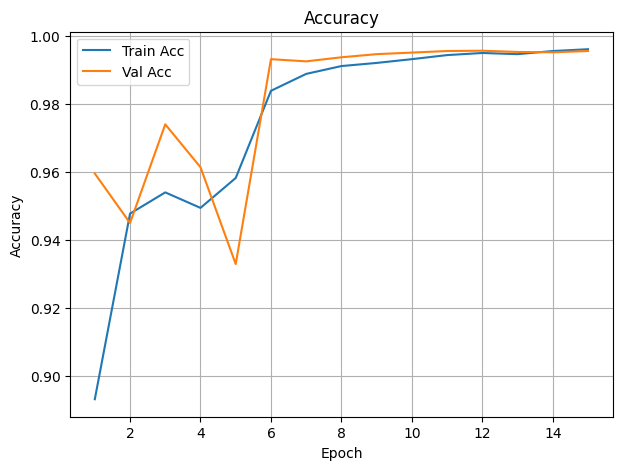

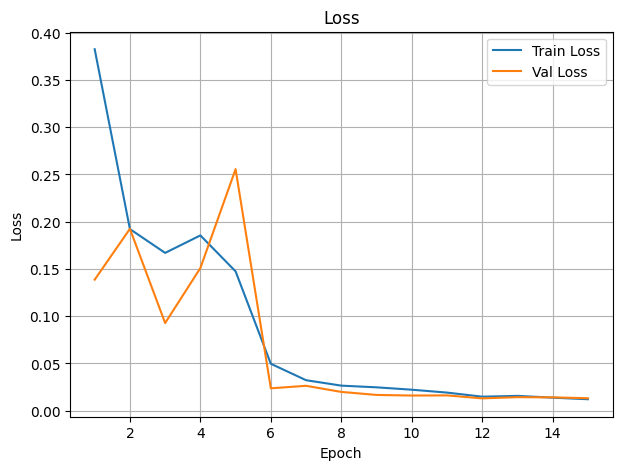

In [10]:
def plot_curves(*histories):
    acc = []; val_acc = []; loss = []; val_loss = []
    for h in histories:
        acc     += h.history.get('accuracy', [])
        val_acc += h.history.get('val_accuracy', [])
        loss    += h.history.get('loss', [])
        val_loss+= h.history.get('val_loss', [])
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.grid(True); plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.grid(True); plt.legend()
    plt.show()

plot_curves(history_s1, history_s2, history_s3)


**Evaluation**


Evaluating on VAL...
Val Loss: 0.0130  Val Acc: 0.9957

Classification report (VAL):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000       126
                                 Apple___Black_rot     1.0000    1.0000    1.0000       125
                          Apple___Cedar_apple_rust     0.9821    1.0000    0.9910        55
                                   Apple___healthy     1.0000    1.0000    1.0000       329
                               Blueberry___healthy     0.9967    0.9967    0.9967       300
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       210
                 Cherry_(including_sour)___healthy     1.0000    0.9941    0.9971       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9394    0.9029    0.9208       103
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000    

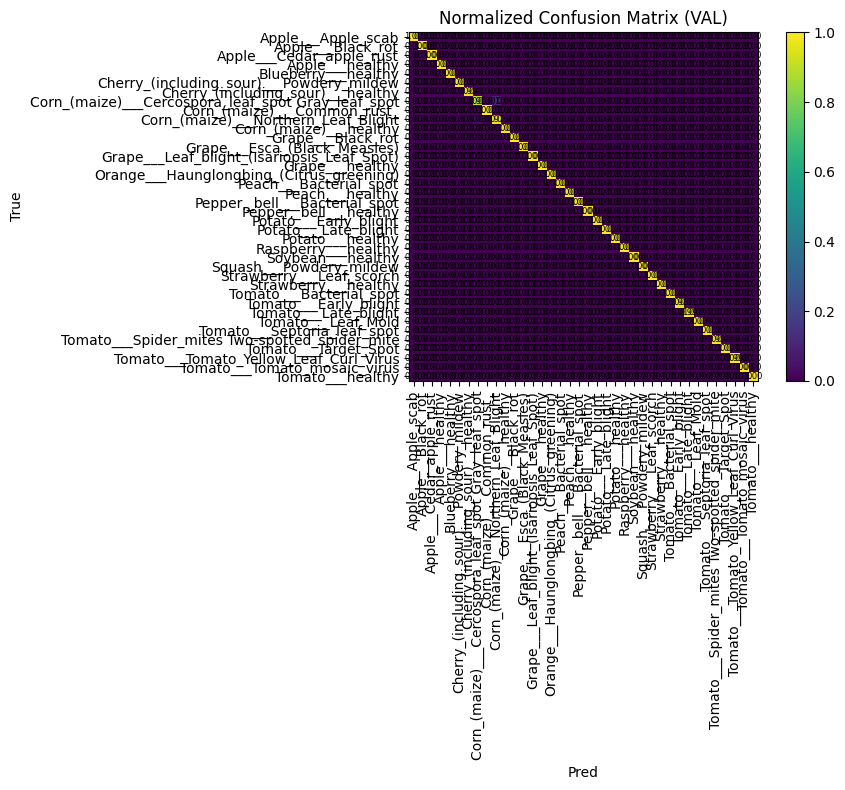

In [11]:
print("\nEvaluating on VAL...")
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

probs_val = model.predict(val_generator, verbose=0)
y_pred_val = np.argmax(probs_val, axis=1)
y_true_val = val_generator.classes

print("\nClassification report (VAL):")
print(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))

cm_val = confusion_matrix(y_true_val, y_pred_val)
def plot_confusion_matrix(cm, classes, normalize=True, title='Normalized Confusion Matrix (VAL)'):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-12)
    plt.figure(figsize=(10,8))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=90)
    plt.yticks(ticks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if i < len(classes) and j < len(classes):
            plt.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6)
    plt.ylabel('True'); plt.xlabel('Pred'); plt.tight_layout(); plt.show()

plot_confusion_matrix(cm_val, class_names, normalize=True)

**Visualization**

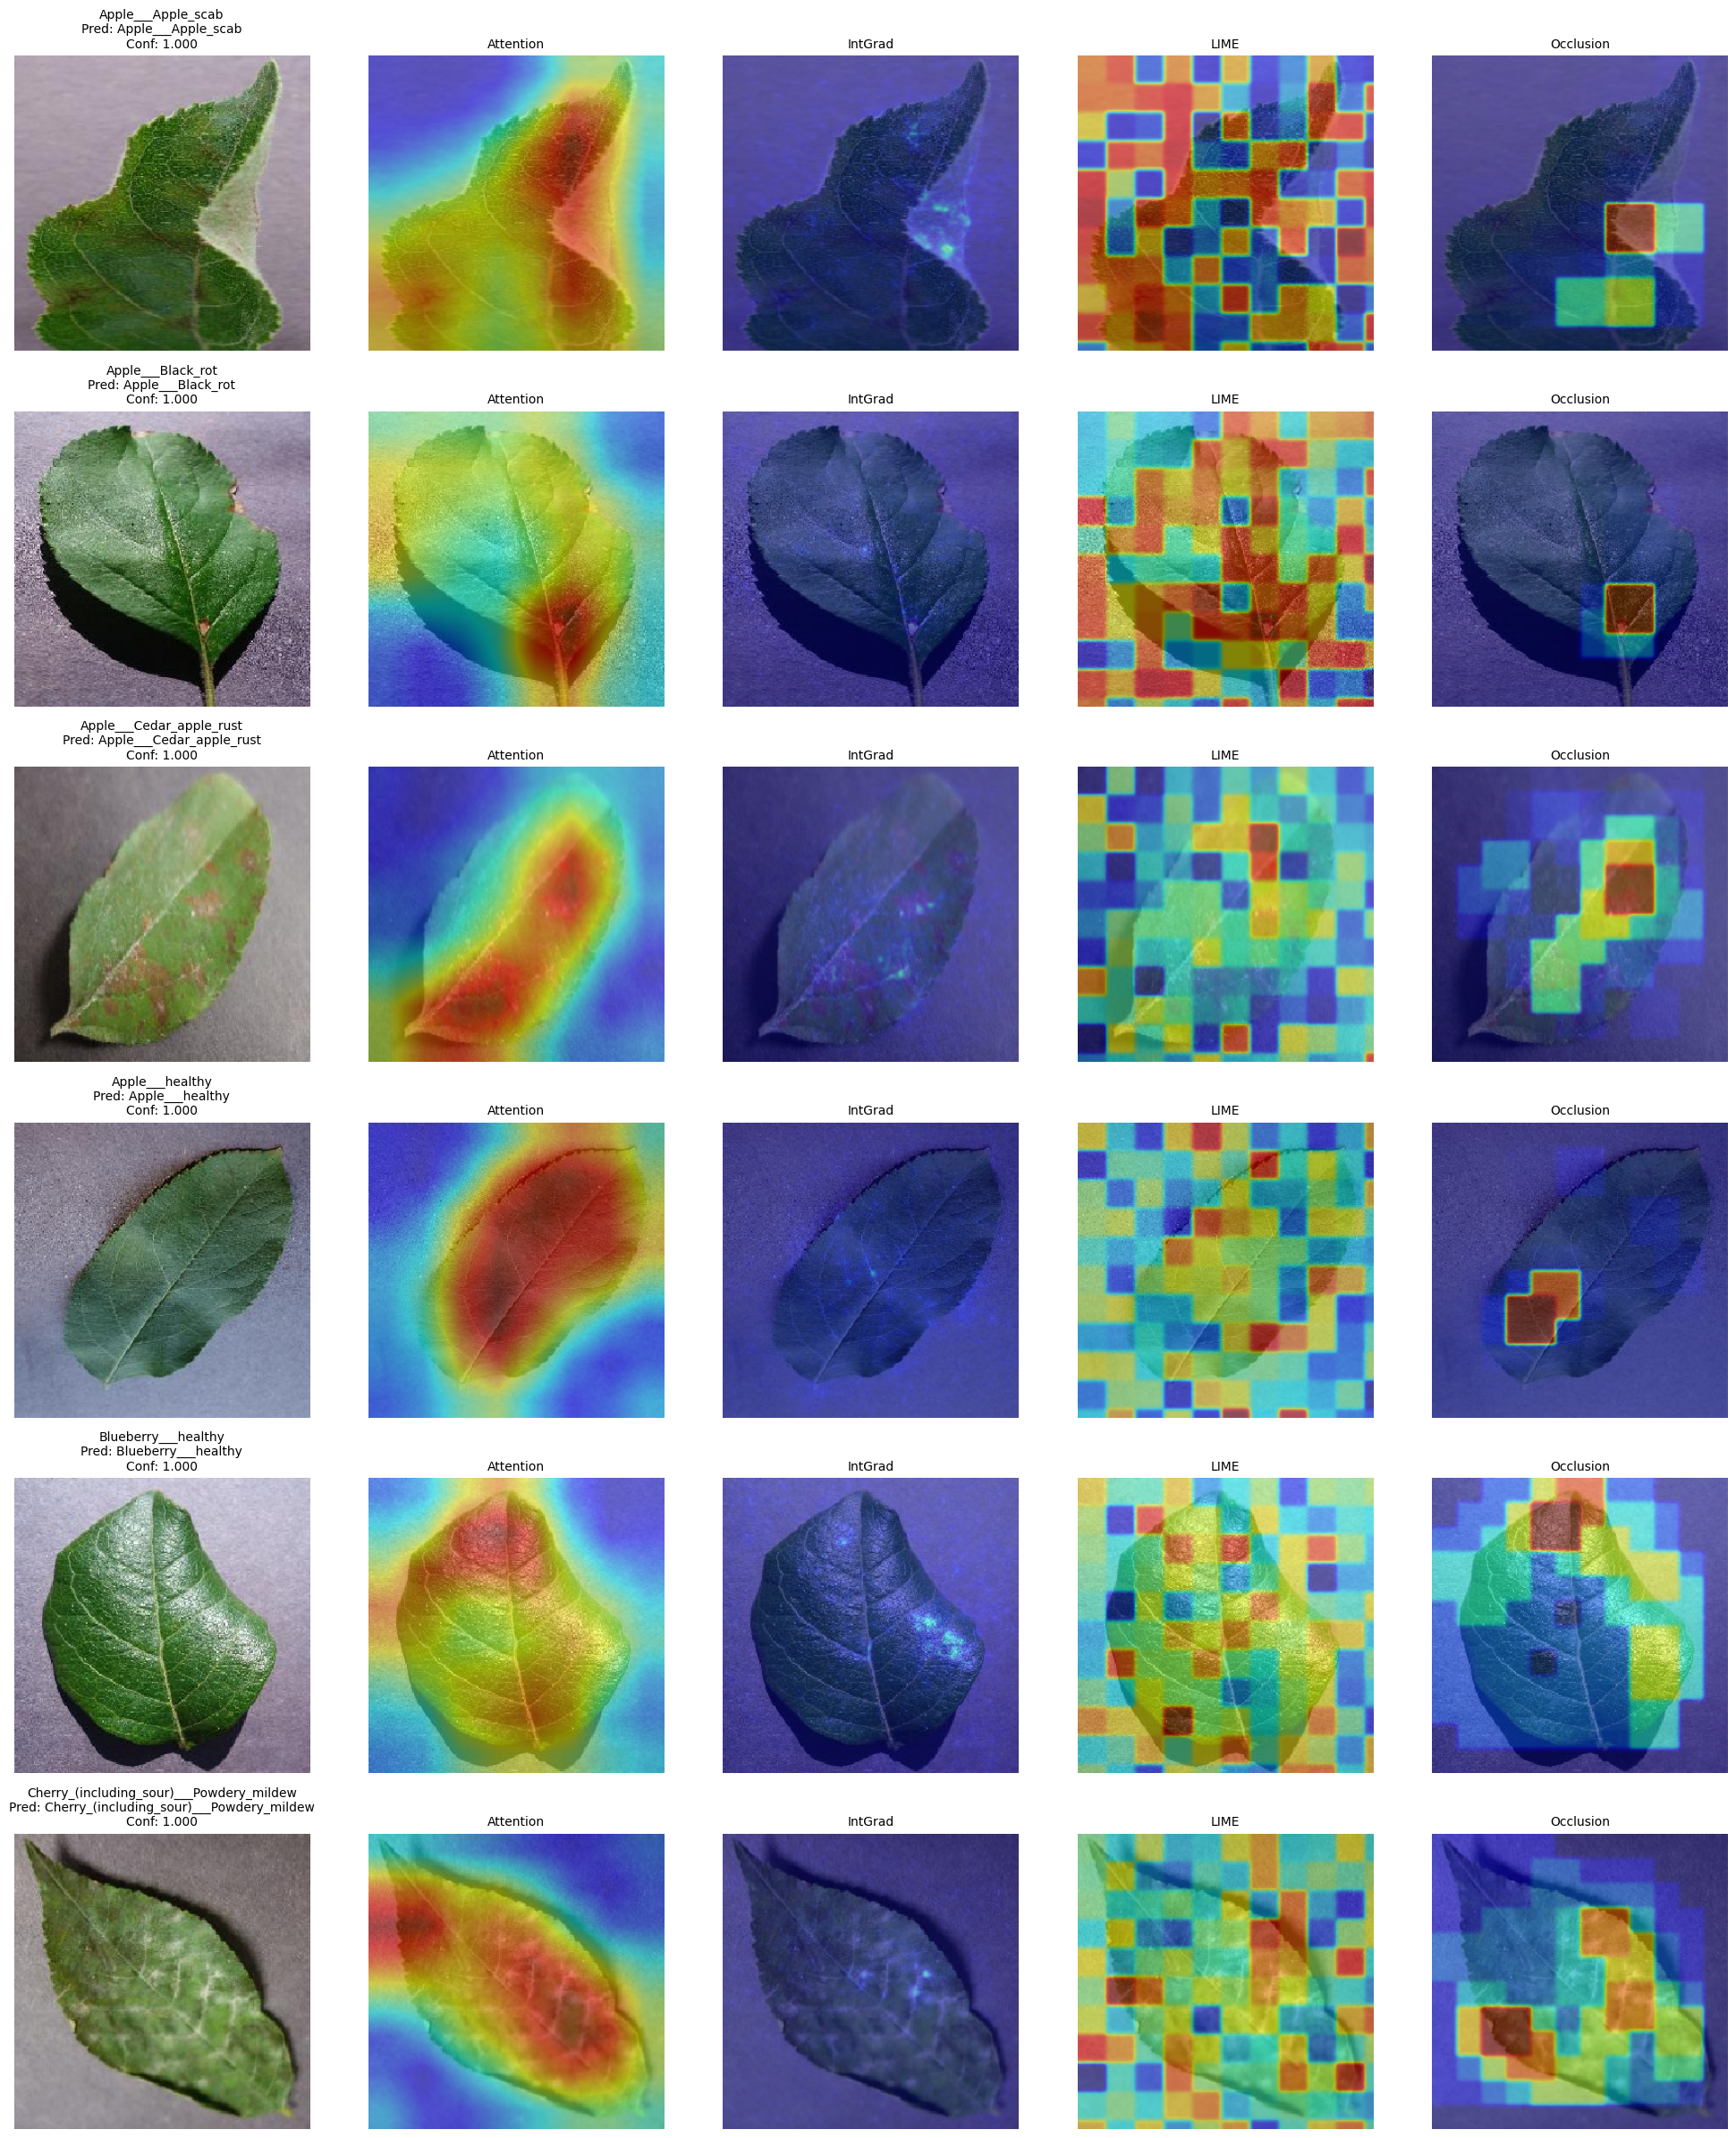


SUMMARY STATISTICS
Total images analyzed: 6
  Occlusion   :  6/6 (100.0%)
  LIME        :  6/6 (100.0%)
  Attention   :  6/6 (100.0%)
  IntGrad     :  6/6 (100.0%)


In [15]:
import numpy as np, tensorflow as tf, cv2, matplotlib.pyplot as plt
from tensorflow import keras
import random, os
from scipy.ndimage import gaussian_filter
from collections import defaultdict

SAMPLE_DIR = "/kaggle/input/plantvillage/PlantVillage/val"


def occlusion_sensitivity(img_array, model, patch_size=32, stride=16, class_index=None):
    original_pred = model(img_array, training=False)
    if class_index is None:
        class_index = np.argmax(original_pred[0])
    original_confidence = float(original_pred[0, class_index])

    h, w = img_array.shape[1:3]
    sensitivity_map = np.zeros((h, w))

    y_positions = range(0, h - patch_size + 1, stride)
    x_positions = range(0, w - patch_size + 1, stride)

    for y in y_positions:
        for x in x_positions:
            occluded_img = img_array.copy()
            occluded_img[:, y:y+patch_size, x:x+patch_size, :] = 128
            occluded_pred = model(occluded_img, training=False)
            occluded_confidence = float(occluded_pred[0, class_index])
            sensitivity = original_confidence - occluded_confidence
            sensitivity_map[y:y+patch_size, x:x+patch_size] = np.maximum(
                sensitivity_map[y:y+patch_size, x:x+patch_size], sensitivity
            )

    if sensitivity_map.max() > 0:
        sensitivity_map = sensitivity_map / sensitivity_map.max()
    return sensitivity_map, class_index, original_confidence


def lime_explanation(img_array, model, num_samples=100, num_features=100, class_index=None):
    original_pred = model(img_array, training=False)
    if class_index is None:
        class_index = np.argmax(original_pred[0])

    h, w = img_array.shape[1:3]
    segment_size = max(h, w) // int(np.sqrt(num_features))

    segments = np.zeros((h, w), dtype=int)
    segment_id = 0
    for y in range(0, h, segment_size):
        for x in range(0, w, segment_size):
            y_end = min(y + segment_size, h)
            x_end = min(x + segment_size, w)
            segments[y:y_end, x:x_end] = segment_id
            segment_id += 1

    num_segments = segment_id
    samples, predictions = [], []

    for _ in range(num_samples):
        sample = np.random.binomial(1, 0.5, num_segments)
        samples.append(sample)
        masked_img = img_array.copy()
        for seg_id in range(num_segments):
            if sample[seg_id] == 0:
                mask = segments == seg_id
                masked_img[0, mask] = 128
        pred = model(masked_img, training=False)
        predictions.append(float(pred[0, class_index]))

    samples, predictions = np.array(samples), np.array(predictions)
    segment_importance = np.zeros(num_segments)
    for seg_id in range(num_segments):
        correlation = np.corrcoef(samples[:, seg_id], predictions)[0, 1]
        segment_importance[seg_id] = correlation if not np.isnan(correlation) else 0

    importance_map = np.zeros((h, w))
    for seg_id in range(num_segments):
        mask = segments == seg_id
        importance_map[mask] = segment_importance[seg_id]

    if importance_map.max() > importance_map.min():
        importance_map = (importance_map - importance_map.min()) / (importance_map.max() - importance_map.min())
    return importance_map, class_index, float(original_pred[0, class_index])


def attention_rollout(img_array, model, class_index=None):
    try:
        reshape_layer = None
        for layer in model.layers:
            if 'reshape' in layer.name.lower():
                reshape_layer = layer
                break
        if reshape_layer is None:
            return None, None, None

        feature_model = keras.Model(inputs=model.input, outputs=reshape_layer.output)
        features = feature_model(img_array, training=False)
        pred = model(img_array, training=False)
        if class_index is None:
            class_index = np.argmax(pred[0])

        spatial_importance = np.mean(np.abs(features[0]), axis=-1)
        spatial_map = spatial_importance.reshape(8, 8)
        spatial_map = spatial_map / (spatial_map.max() + 1e-7)
        return spatial_map, class_index, float(pred[0, class_index])
    except:
        return None, None, None


def integrated_gradients_input(img_array, model, steps=50, class_index=None):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    baseline = tf.zeros_like(img_tensor)

    pred = model(img_tensor, training=False)
    if class_index is None:
        class_index = tf.argmax(pred[0])

    alphas = tf.linspace(start=0.0, stop=1.0, num=steps + 1)
    integrated_grads = tf.zeros_like(img_tensor)

    for alpha in alphas:
        interpolated = baseline + alpha * (img_tensor - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = model(interpolated, training=False)
            class_score = pred[:, class_index]
        grads = tape.gradient(class_score, interpolated)
        if grads is not None:
            integrated_grads += grads

    integrated_grads = integrated_grads / len(alphas)
    integrated_grads = (img_tensor - baseline) * integrated_grads
    importance_map = tf.reduce_mean(tf.abs(integrated_grads[0]), axis=-1)
    importance_map = importance_map / (tf.reduce_max(importance_map) + 1e-7)
    return importance_map.numpy(), int(class_index), float(pred[0, class_index])


def create_overlay(img_array, heatmap, alpha=0.4):
    h, w = img_array.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_smooth = gaussian_filter(heatmap_resized, sigma=2.0)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_smooth), cv2.COLORMAP_JET)
    img_bgr = cv2.cvtColor(img_array.astype(np.uint8), cv2.COLOR_RGB2BGR)
    overlay = cv2.addWeighted(img_bgr, 1-alpha, heatmap_colored, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)


def get_diverse_images(sample_dir, num_images=6):
    class_images = defaultdict(list)
    for class_folder in sorted(os.listdir(sample_dir)):
        class_path = os.path.join(sample_dir, class_folder)
        if not os.path.isdir(class_path):
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")):
                img_path = os.path.join(class_path, img_file)
                class_images[class_folder].append(img_path)

    selected_images = []
    class_names_list = list(class_images.keys())
    for i in range(min(num_images, len(class_names_list))):
        class_name = class_names_list[i]
        if class_images[class_name]:
            random.seed(42 + i)
            img_path = random.choice(class_images[class_name])
            selected_images.append((img_path, class_name))

    while len(selected_images) < num_images and len(class_images) > 0:
        for class_name, images in class_images.items():
            if len(selected_images) >= num_images:
                break
            if len(images) > 1:
                remaining_images = [img for img in images if img not in [sel[0] for sel in selected_images]]
                if remaining_images:
                    img_path = random.choice(remaining_images)
                    selected_images.append((img_path, f"{class_name}_2"))
    return selected_images[:num_images]


def analyze_single_image(img_path, class_name, model, target_size=(299, 299)):
    img = keras.utils.load_img(img_path, target_size=target_size)
    img_array = keras.utils.img_to_array(img).astype("float32")
    img_batch = np.expand_dims(img_array, axis=0)

    pred = model(img_batch, training=False)
    predicted_class = np.argmax(pred[0])
    confidence = float(pred[0, predicted_class])

    if 'class_names' in globals() and class_names is not None:
        pred_label = class_names[predicted_class] if 0 <= predicted_class < len(class_names) else f"Class {predicted_class}"
    else:
        pred_label = f"Class {predicted_class}"

    methods = [
        ("Occlusion", lambda: occlusion_sensitivity(img_batch, model, patch_size=50, stride=25)),
        ("LIME", lambda: lime_explanation(img_batch, model, num_samples=30)),
        ("Attention", lambda: attention_rollout(img_batch, model)),
        ("IntGrad", lambda: integrated_gradients_input(img_batch, model, steps=20))
    ]

    results = []
    for name, method in methods:
        try:
            result = method()
            if result[0] is not None:
                results.append((name, *result))
        except:
            pass
    return img_array, results, class_name, pred_label, confidence


def create_comprehensive_comparison(selected_images, model):
    all_results = []
    for img_path, class_name in selected_images:
        img_array, results, actual_class, pred_label, confidence = analyze_single_image(
            img_path, class_name, model
        )
        all_results.append((img_array, results, actual_class, pred_label, confidence))

    n_images = len(all_results)
    successful_methods = set()
    for _, results, _, _, _ in all_results:
        for method_name, _, _, _ in results:
            successful_methods.add(method_name)
    successful_methods = sorted(list(successful_methods))
    n_methods = len(successful_methods)
    if n_methods == 0:
        return

    fig, axes = plt.subplots(n_images, n_methods + 1, figsize=(4 * (n_methods + 1), 4 * n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)

    for img_idx, (img_array, results, actual_class, pred_label, confidence) in enumerate(all_results):
        axes[img_idx, 0].imshow(img_array.astype(np.uint8))
        axes[img_idx, 0].set_title(f"{actual_class}\nPred: {pred_label}\nConf: {confidence:.3f}", fontsize=10)
        axes[img_idx, 0].axis('off')
        results_dict = {name: (heatmap, class_idx, conf) for name, heatmap, class_idx, conf in results}
        for method_idx, method_name in enumerate(successful_methods):
            col = method_idx + 1
            if method_name in results_dict:
                heatmap, _, _ = results_dict[method_name]
                overlay = create_overlay(img_array, heatmap, alpha=0.5)
                axes[img_idx, col].imshow(overlay)
                axes[img_idx, col].set_title(method_name, fontsize=10)
            else:
                axes[img_idx, col].set_facecolor('lightgray')
            axes[img_idx, col].axis('off')
    plt.tight_layout()
    plt.show()

    method_success_count = defaultdict(int)
    total_images = len(all_results)
    for _, results, _, _, _ in all_results:
        for method_name, _, _, _ in results:
            method_success_count[method_name] += 1

    print(f"\nSUMMARY STATISTICS")
    print(f"Total images analyzed: {total_images}")
    for method_name in ["Occlusion", "LIME", "Attention", "IntGrad"]:
        success_rate = method_success_count[method_name] / total_images * 100
        print(f"  {method_name:12s}: {method_success_count[method_name]:2d}/{total_images} ({success_rate:5.1f}%)")


selected_images = get_diverse_images(SAMPLE_DIR, num_images=6)
results = create_comprehensive_comparison(selected_images, model)
